In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Read the dataset
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Check dataset structure
print(data.shape)
print(data.info())
print(data.describe())

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500

In [4]:
# Check missing values
print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
# Remove unnecessary customer ID column
data = data.drop("CustomerID", axis=1)
print(data.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


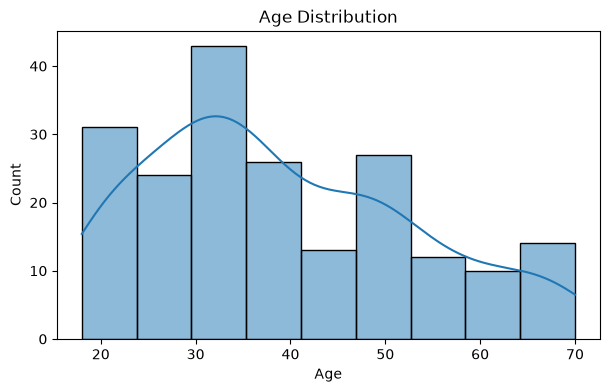

In [6]:
# Show age distribution
plt.figure(figsize=(7,4))
sns.histplot(data["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

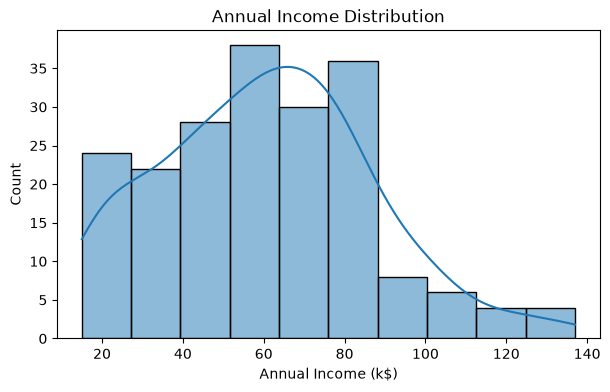

In [7]:
# Show annual income distribution
plt.figure(figsize=(7,4))
sns.histplot(data["Annual Income (k$)"], kde=True)
plt.title("Annual Income Distribution")
plt.show()

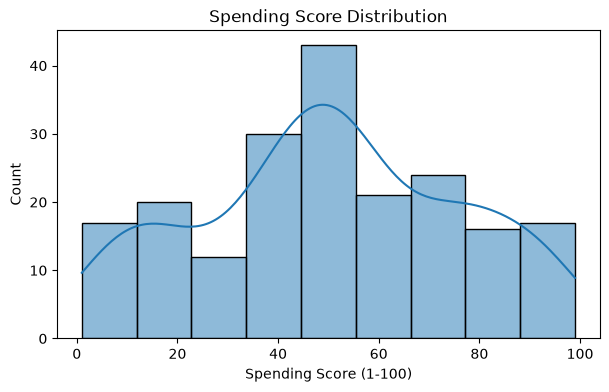

In [8]:
# Show spending score distribution
plt.figure(figsize=(7,4))
sns.histplot(data["Spending Score (1-100)"], kde=True)
plt.title("Spending Score Distribution")
plt.show()

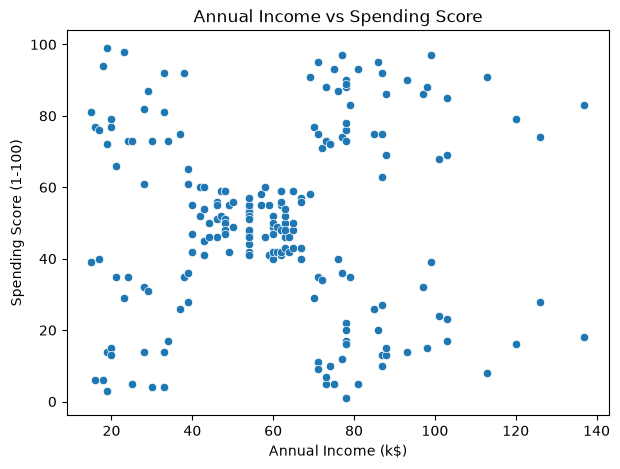

In [9]:
# Compare income and spending score
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

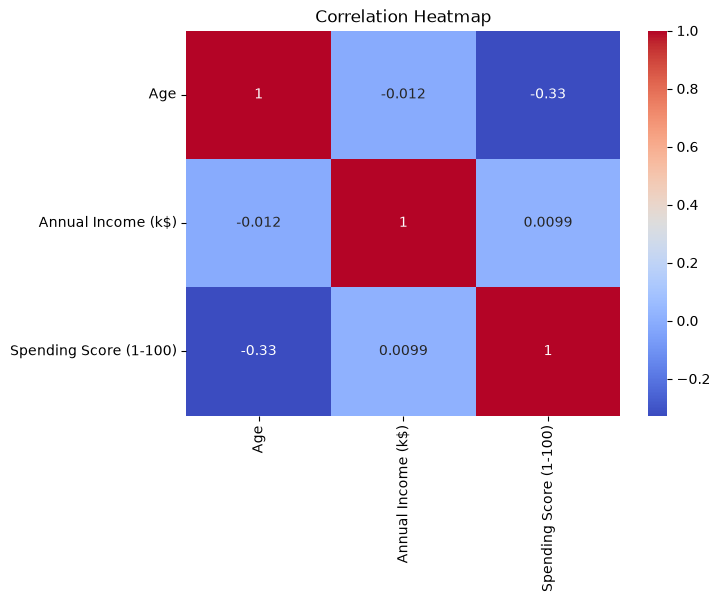

In [11]:
# Show correlation between numerical features
plt.figure(figsize=(7,5))
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Select features for clustering
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [13]:
# Standardise the clustering features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

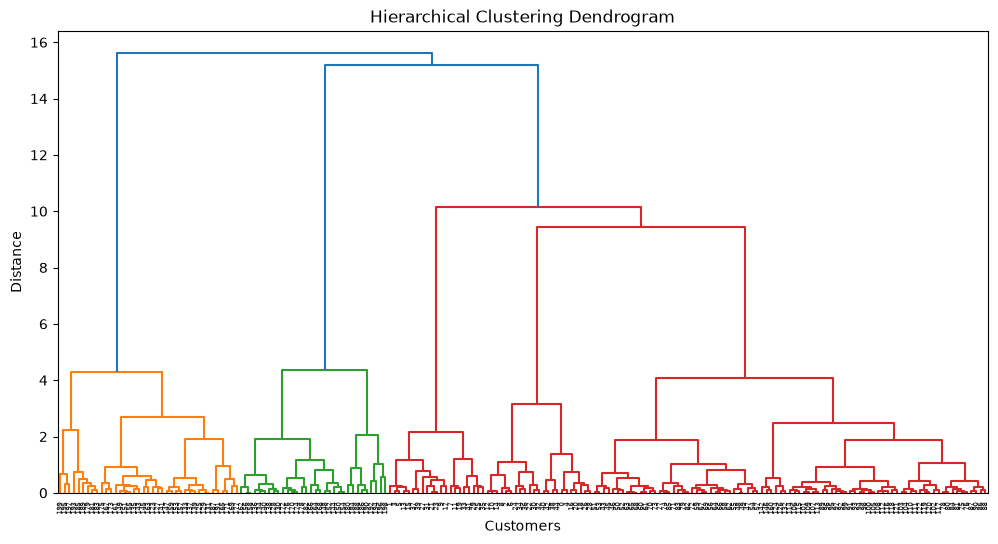

In [14]:
# Create dendrogram
plt.figure(figsize=(12,6))
linkage_data = linkage(X_scaled, method="ward")
dendrogram(linkage_data)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [15]:
# Create hierarchical clustering model
model = AgglomerativeClustering(n_clusters=5, linkage="ward")
clusters = model.fit_predict(X_scaled)

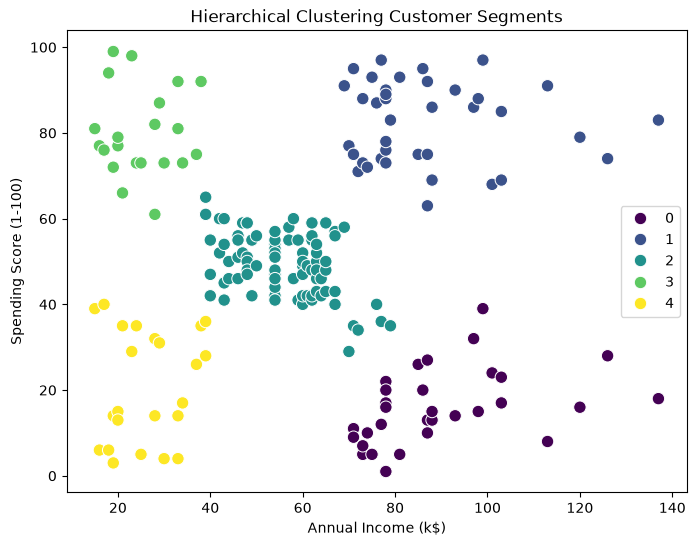

In [16]:
# Plot the customer clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X["Annual Income (k$)"], y=X["Spending Score (1-100)"], hue=clusters, palette="viridis", s=80)
plt.title("Hierarchical Clustering Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [18]:
# Add cluster labels and show cluster averages
data["Cluster"] = clusters
print(data.groupby("Cluster").mean(numeric_only=True))

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.000000           89.406250               15.593750
1        32.692308           86.538462               82.128205
2        42.482353           55.811765               49.129412
3        25.333333           25.095238               80.047619
4        45.217391           26.304348               20.913043


In [19]:
# Calculate silhouette score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5538089226688662


In [20]:
# Check silhouette score for different cluster numbers
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print("Clusters:", k, "Silhouette Score:", score)

Clusters: 2 Silhouette Score: 0.3842337621772661
Clusters: 3 Silhouette Score: 0.4610481446570447
Clusters: 4 Silhouette Score: 0.4925507715349343
Clusters: 5 Silhouette Score: 0.5538089226688662
Clusters: 6 Silhouette Score: 0.5386761871036926
Clusters: 7 Silhouette Score: 0.5197949293475768
Clusters: 8 Silhouette Score: 0.4308617778221774


In [21]:
# Train the final hierarchical clustering model
final_model = AgglomerativeClustering(n_clusters=5, linkage="ward")
final_clusters = final_model.fit_predict(X_scaled)
final_score = silhouette_score(X_scaled, final_clusters)
print("Final Silhouette Score:", final_score)
print("Number of Clusters:", len(np.unique(final_clusters)))

Final Silhouette Score: 0.5538089226688662
Number of Clusters: 5
